# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [ ]:
#Importação pacote
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#CSV
df_genes = pd.read_csv("./data/df_genes_aula6exer7.csv", index_col="Unnamed: 0")
df_genes.head()

,num_letras,primeiras_duas_letras,num_a,contains_hu
isg15,5,is,0,False
hur,3,hu,0,True
ifna,4,if,1,False
tnfa,4,tn,1,False
atpsf1a,7,at,2,False


In [78]:
df_genes['id_entrez'] = [
    "NM_005101.4",
    "NM_001419.3",
    "NM_024013.3",
    "NM_001270508.2",
    "NM_004046.6",
]

df_genes['id_protein'] = [
    'NP_005092.1',
    "NP_001410.2",
    "NP_000596.2",
    "NP_001257437.1",
    "NP_004037.1",
]
df_genes

,num_letras,primeiras_duas_letras,num_a,contains_hu,id_entrez,id_protein
isg15,5,is,0,False,NM_005101.4,NP_005092.1
hur,3,hu,0,True,NM_001419.3,NP_001410.2
ifna,4,if,1,False,NM_024013.3,NP_000596.2
tnfa,4,tn,1,False,NM_001270508.2,NP_001257437.1
atpsf1a,7,at,2,False,NM_004046.6,NP_004037.1


In [ ]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./exercicios/data/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [ ]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  #Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

isg15 NP_005092.1
hur NP_001410.2
ifna NP_000596.2
tnfa NP_001257437.1
atpsf1a NP_004037.1


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [ ]:
#Importação pacotes
import pandas as pd
import os
from Bio import SeqIO
#Lista dos aminoácidos
aminoacidos = list("ARNDCQEGHILKMFPSTWYV")
#Chamando os arquivos fasta
pasta_fasta = "."
dados = []

for arquivo in os.listdir(pasta_fasta):
    if arquivo.endswith(".fasta"):
        
        nome_gene = arquivo.replace(".fasta", "")
        caminho = arquivo 
        
        print("Lendo:", caminho)
        
        seq = ""
        for record in SeqIO.parse(caminho, "fasta"):
            seq = str(record.seq)
        
        contagem = {}
        for aa in aminoacidos:
            contagem[aa] = seq.count(aa)
        
        contagem["gene"] = nome_gene
        dados.append(contagem)

df_freq = pd.DataFrame(dados).set_index("gene")
print(df_freq)

Lendo: atpsf1a.fasta
Lendo: Hur.fasta
Lendo: ifna.fasta
Lendo: isg15.fasta
Lendo: tnfa.fasta
          A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T  \
gene                                                                          
atpsf1a  58  38  16  29   2  25  31  51   7  39  53  30  12  16  18  39  27   
Hur      23  20  23  16   3  12  15  29   8  19  22  18  10  18  12  28  16   
ifna     11  10   4   8   6  12  14   6   3   8  27  11   6  11   5  18  11   
isg15     7   8   4   7   1  12   9  18   3   3  24   8   4   5   8  15   9   
tnfa     50  56  40  30  40  39  57  45  30  27  64  46  20  34  56  53  47   

         W   Y   V  
gene                
atpsf1a  0  16  46  
Hur      2  10  22  
ifna     2   5  10  
isg15    2   2  16  
tnfa     9  18  29  


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [ ]:
valinas = df_freq["V"]
print("Número de valinas por gene:")
print(valinas)
print("Gene com mais valinas")
print(valinas.idxmax())
print("Quantidade de valinas")
print(valinas.max())

Número de valinas por gene:
gene
atpsf1a    46
Hur        22
ifna       10
isg15      16
tnfa       29
Name: V, dtype: int64
Gene com mais valinas
atpsf1a
Quantidade de valinas
46


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [ ]:
serina = df_freq["S"]
#Media
media = serina.mean()
#Mediana
mediana = serina.median()
#Moda
if not serina.mode().empty:
    moda = serina.mode()[0]
else:
    moda = None
print("Média:", round(media, 2))
print("Mediana:", mediana)
print("Moda:", moda)

Média: 30.6
Mediana: 28.0
Moda: 15


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

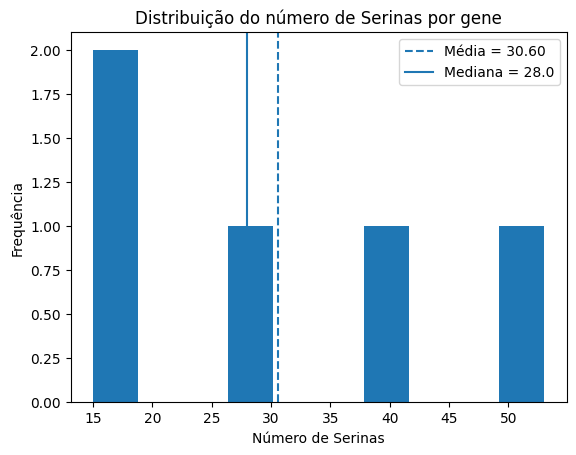

In [ ]:
#Importação pacotes
import matplotlib.pyplot as plt
#Serina
serina = df_freq["S"]
# Calcula média e mediana
media = serina.mean()
mediana = serina.median()
#Histograma
plt.figure()
plt.hist(serina)
plt.axvline(media, linestyle='--', label=f"Média = {media:.2f}") #media tracejada
plt.axvline(mediana, linestyle='-', label=f"Mediana = {mediana}") #mediana contínua
plt.title("Distribuição do número de Serinas por gene")
plt.xlabel("Número de Serinas")
plt.ylabel("Frequência")
plt.legend()
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

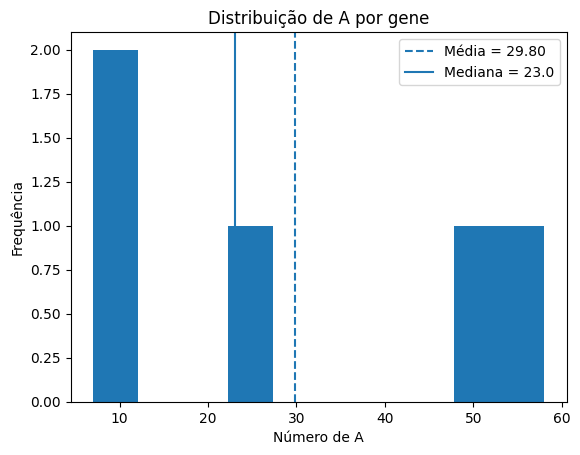

In [ ]:
#Importação pacotes
import pandas as pd
import os
from Bio import SeqIO
import matplotlib.pyplot as plt
#Retomada do codigo
aminoacidos = list("ARNDCQEGHILKMFPSTWYV")
pasta_fasta = "."  
dados = []
for arquivo in os.listdir(pasta_fasta):
    if arquivo.endswith(".fasta"):
        
        nome_gene = arquivo.replace(".fasta", "")
        
        seq = ""
        for record in SeqIO.parse(arquivo, "fasta"):
            seq = str(record.seq)
        
        contagem = {}
        for aa in aminoacidos:
            contagem[aa] = seq.count(aa)
        
        contagem["gene"] = nome_gene
        dados.append(contagem)

df_freq = pd.DataFrame(dados).set_index("gene")
#Exercicio 6
def histograma_aa(df, aa):
    aa = aa.upper()
    
    # Verifica se o aminoácido existe
    if aa not in df.columns:
        print(f"Aminoácido '{aa}' não encontrado no DataFrame.")
        return
    
    valores = df[aa]
    #Valores
    media = valores.mean()
    mediana = valores.median()
    #Histograma
    plt.figure()
    plt.hist(valores)
    plt.axvline(media, linestyle='--', label=f"Média = {media:.2f}")
    plt.axvline(mediana, linestyle='-', label=f"Mediana = {mediana}")
    plt.title(f"Distribuição de {aa} por gene")
    plt.xlabel(f"Número de {aa}")
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()
histograma_aa(df_freq, "A") #Alanina

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

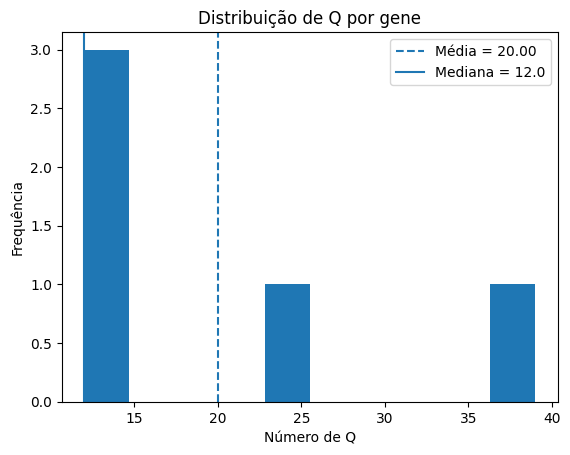

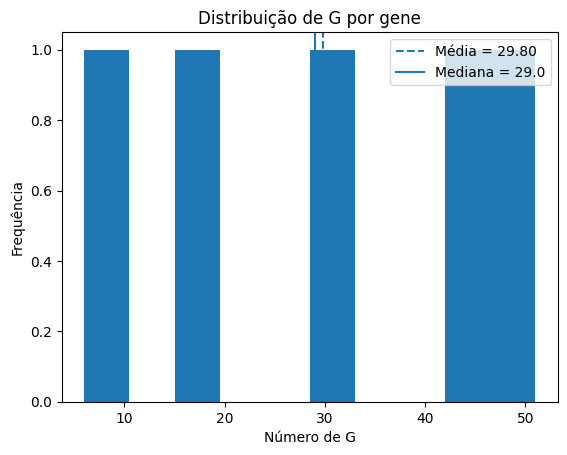

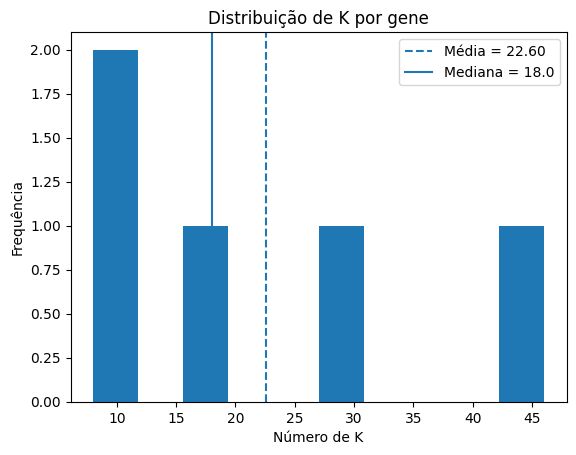

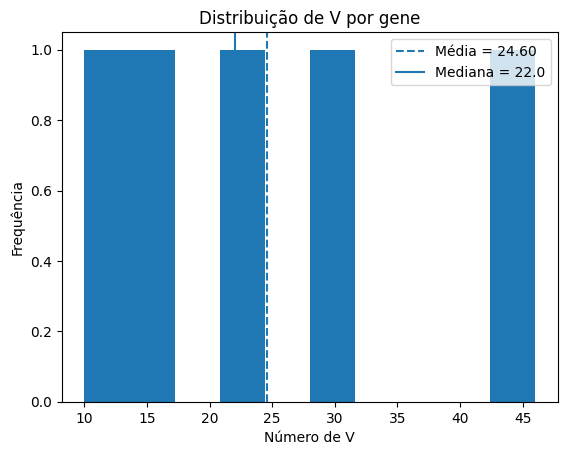


Diferença entre média e mediana:

Q: 8.00
G: 0.80
K: 4.60
V: 2.60

Aminoácido com menor diferença entre média e mediana:
G


In [ ]:
#Lista aa do exercicio:
aminoacidos_teste = ["Q", "G", "K", "V"]
diferencas = {}
for aa in aminoacidos_teste:
    histograma_aa(df_freq, aa) #histograma
    valores = df_freq[aa] #calculo dos valores
    media = valores.mean()
    mediana = valores.median()
    diferenca = abs(media - mediana)
    diferencas[aa] = diferenca
print("Diferença entre média e mediana:")
for aa, dif in diferencas.items():
    print(f"{aa}: {dif:.2f}")
#Aa com menos diferença:
menor = min(diferencas, key=diferencas.get)
print("Aminoácido com menor diferença entre média e mediana:")
print(menor)

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [6]:
#3 primeiros genes
primeiros_genes = df_freq.head(3)
#Seleção cisteina
cisteina = primeiros_genes["C"]
#Valores 
media = cisteina.mean()
mediana = cisteina.median()
print("Média de Cisteína:", media)
print("Mediana de Cisteína:", mediana)

Média de Cisteína: 3.6666666666666665
Mediana de Cisteína: 3.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [8]:
#Média de aminoácidos por gene
media_por_gene = df_freq.mean(axis=1)
print("Média de aa por gene:")
print(media_por_gene)
# Gene com maior média
maior_gene = media_por_gene.idxmax()
valor = media_por_gene.max()
print("Gene com maior número médio de aa:")
print(maior_gene)
print("Valor médio:")
print(valor)

Média de aa por gene:
gene
atpsf1a    27.65
Hur        16.30
ifna        9.40
isg15       8.25
tnfa       39.50
dtype: float64
Gene com maior número médio de aa:
tnfa
Valor médio:
39.5


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [ ]:
#Média de aa por gene
media_por_gene = df_freq.mean(axis=1)
print("Média de aa por gene:")
print(media_por_gene)
#Gene com menor média
menor_gene = media_por_gene.idxmin()
valor = media_por_gene.min()
print("Gene com menor número médio de aa:")
print(menor_gene)
print("Valor médio de aa:")
print(valor)

Média de aa por gene:
gene
atpsf1a    27.65
Hur        16.30
ifna        9.40
isg15       8.25
tnfa       39.50
dtype: float64
Gene com menor número médio de aa:
isg15
Valor médio de aa:
8.25
